# Chapter 16: Computer Animation

Source orientation: *Fundamentals of Computer Graphics*, Chapter 16, printed pages 429-460, physical PDF pages 446-477. This notebook uses that span for topic coverage and terminology, then builds original computational examples.

## Chapter Goal

Computer animation is the problem of controlling change over time. The animator supplies sparse intent: key poses, timing, constraints, procedures, forces, or captured motion. The computer fills in values at frame times, but the fill-in must preserve the things that make motion readable: path shape, speed, orientation, volume, joint constraints, numerical stability, and priority among competing controls.

The practical question for this notebook is: **what should we measure when an animation looks wrong?** We will turn the chapter's ideas into small, inspectable diagnostics. Each visual below has a target: a learner should be able to point to a path, frame sample, tangent, quaternion, skeleton, or update rule and say which invariant is being protected.

## Translation guide

| Chapter idea | Computational object | What can go wrong | Diagnostic used here |
| --- | --- | --- | --- |
| Keyframes | pairs `(time, value)` for positions, colors, transforms, or parameters | too many keys, missing keys, bad tangents, overshoot | interpolation error at keys, tangent and speed plots |
| Catmull-Rom and TCB splines | piecewise cubic Hermite curves with incoming/outgoing tangents | C0 path is correct but velocity jumps or kinks appear | speed continuity and local TCB comparisons |
| Motion control | spatial curve `P(u)` composed with distance law `s(t)` | path shape and timing are accidentally coupled | arc-length table, per-frame distance statistics |
| Timing, slow-in/slow-out, aliasing | sampled frame sequence and velocity profile | frame-to-frame displacement exceeds readable overlap | distance-per-frame and squash/stretch area checks |
| Rotation | unit quaternions and rotation matrices | elementwise matrix interpolation leaves the rotation group; Euler angles can lock axes | determinant, orthonormality, quaternion norm, angular step size |
| Character animation | forward/inverse kinematics and skinning weights | end effector misses, Jacobian is wrong, skin weights do not blend | IK residual, finite-difference Jacobian check, weight sum check |
| Automatic methods | finite-difference physics, procedural functions, group steering | instability, hard-to-control parameters, urge cancellation | energy growth, wave parameter exposure, acceleration budget |

## Visual storyboard

1. Fit sparse keys with Catmull-Rom and TCB controls, then inspect the curve and derivative rather than just the posed values.
2. Separate the path `P(u)` from timing `s(t)` with an arc-length table, then compare raw parameter samples, constant-speed samples, and eased samples.
3. Make a timing lab for frame sampling and squash/stretch: if a moving object has no overlap between frames, a pose may be mathematically correct but visually unreadable.
4. Interpolate orientation with quaternions, while showing why matrix lerp fails the rotation-matrix tests.
5. Build a two-link character control example with FK, IK, and a Jacobian, then show a skinning weight blend around the joint.
6. Close with compact automatic-method diagnostics for physics, procedural waves, and prioritized group steering.
7. Save an animation sanity JSON that records the core numeric invariants and artifact checks.

## Library Routing

Matplotlib is used for durable 2D diagnostics where exact labels and saved PNG artifacts matter. Plotly is used for the quaternion orientation frame because a 3D transform is easier to inspect when the frame can be rotated in a browser. NumPy handles arrays, arc-length tables, quaternions, Jacobians, and finite differences; no shared helper or global course script is edited.

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np

starts = [Path.cwd().resolve(), (Path.cwd() / "Fundamentals-of-Computer-Graphics").resolve()]
candidates = []
for start in starts:
    candidates.extend([start, *start.parents])

BOOK_ROOT = None
for candidate in candidates:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not find the FCG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, book_relative, display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.notebook_checks import assert_nonblank_image

CHAPTER = 16
TITLE = "Computer Animation"
TOPIC = f"chapter-{CHAPTER:02d}"
PRINTED_PAGES = "429-460"
PDF_PAGES = "446-477"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
for kind in ["figures", "html", "checks", "tables", "data"]:
    (ARTIFACT_ROOT / kind).mkdir(parents=True, exist_ok=True)

figure_paths = []
html_paths = []
check_paths = []

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

print(book_relative(ARTIFACT_ROOT))

artifacts/chapter-16


## 1. Keys Are Intent; Curves Are Commitments

A key is a time/value pair. For a 3D object that value might be a position, color, scale, orientation, light intensity, deformation parameter, or camera control. The book emphasizes that keys for different parameters need not occur at the same frames. The closer keys are, the more direct control the animator has, but the less the computer is doing.

The first diagnostic uses sparse position keys. Catmull-Rom interpolation gives an initial curve because it passes through the keys and estimates tangents automatically. TCB controls then expose a local editor's vocabulary: tension scales tangents, continuity allows incoming and outgoing tangents to differ, and bias pulls a segment toward one neighbor or the other. The check is not simply that the curve passes through the keys. The derivative tells us whether velocity changes smoothly enough to read as intentional motion.

In [2]:
def smoothstep(x):
    x = np.clip(np.asarray(x, dtype=float), 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)


def tcb_tangents(times, values, tension=0.0, continuity=0.0, bias=0.0):
    times = np.asarray(times, dtype=float)
    values = np.asarray(values, dtype=float)
    scalar = values.ndim == 1
    if scalar:
        values = values[:, None]
    n = len(times)
    tin = np.zeros_like(values)
    tout = np.zeros_like(values)
    for k in range(n):
        if k == 0:
            slope = (values[1] - values[0]) / (times[1] - times[0])
            tin[k] = slope
            tout[k] = slope
        elif k == n - 1:
            slope = (values[-1] - values[-2]) / (times[-1] - times[-2])
            tin[k] = slope
            tout[k] = slope
        else:
            d_next = (values[k + 1] - values[k]) / (times[k + 1] - times[k])
            d_prev = (values[k] - values[k - 1]) / (times[k] - times[k - 1])
            tin[k] = 0.5 * (1.0 - tension) * ((1.0 - continuity) * (1.0 + bias) * d_next + (1.0 + continuity) * (1.0 - bias) * d_prev)
            tout[k] = 0.5 * (1.0 - tension) * ((1.0 + continuity) * (1.0 + bias) * d_next + (1.0 - continuity) * (1.0 - bias) * d_prev)
    if scalar:
        return tin[:, 0], tout[:, 0]
    return tin, tout


def hermite_eval(p0, p1, m0, m1, tau, dt):
    tau = np.asarray(tau, dtype=float)
    h00 = 2 * tau**3 - 3 * tau**2 + 1
    h10 = tau**3 - 2 * tau**2 + tau
    h01 = -2 * tau**3 + 3 * tau**2
    h11 = tau**3 - tau**2
    return h00[..., None] * p0 + h10[..., None] * dt * m0 + h01[..., None] * p1 + h11[..., None] * dt * m1


def hermite_derivative(p0, p1, m0, m1, tau, dt):
    tau = np.asarray(tau, dtype=float)
    dh00 = 6 * tau**2 - 6 * tau
    dh10 = 3 * tau**2 - 4 * tau + 1
    dh01 = -6 * tau**2 + 6 * tau
    dh11 = 3 * tau**2 - 2 * tau
    return (dh00[..., None] * p0 + dh10[..., None] * dt * m0 + dh01[..., None] * p1 + dh11[..., None] * dt * m1) / dt


def evaluate_tcb(times, values, query, tension=0.0, continuity=0.0, bias=0.0, derivative=False):
    times = np.asarray(times, dtype=float)
    values = np.asarray(values, dtype=float)
    scalar = values.ndim == 1
    values2 = values[:, None] if scalar else values
    tin, tout = tcb_tangents(times, values2, tension, continuity, bias)
    query = np.asarray(query, dtype=float)
    result = np.empty((query.size, values2.shape[1]), dtype=float)
    for out_i, q in enumerate(query):
        if q <= times[0]:
            seg = 0
        elif q >= times[-1]:
            seg = len(times) - 2
        else:
            seg = np.searchsorted(times, q, side="right") - 1
        dt = times[seg + 1] - times[seg]
        tau = (q - times[seg]) / dt
        fn = hermite_derivative if derivative else hermite_eval
        result[out_i] = fn(values2[seg], values2[seg + 1], tout[seg], tin[seg + 1], np.array([tau]), dt)[0]
    return result[:, 0] if scalar else result


key_times = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
key_values = np.array([0.0, 1.35, 0.55, 1.8, 1.1])
path_keys = np.array([[0.0, 0.0], [1.15, 1.25], [2.15, 0.25], [3.10, 1.65], [4.00, 1.20]])
dense_t = np.linspace(key_times[0], key_times[-1], 480)

curves = {
    "Catmull-Rom default": dict(tension=0.0, continuity=0.0, bias=0.0, color="#2455a4"),
    "higher tension": dict(tension=0.62, continuity=0.0, bias=0.0, color="#c43c39"),
    "positive bias": dict(tension=0.0, continuity=0.0, bias=0.65, color="#2a8f5a"),
    "continuity kink": dict(tension=0.0, continuity=0.72, bias=0.0, color="#7c4d9e"),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
for label, opts in curves.items():
    params = {k: opts[k] for k in ["tension", "continuity", "bias"]}
    axes[0].plot(dense_t, evaluate_tcb(key_times, key_values, dense_t, **params), label=label, color=opts["color"], lw=2)
    axes[1].plot(dense_t, evaluate_tcb(key_times, key_values, dense_t, **params, derivative=True), label=label, color=opts["color"], lw=2)
axes[0].scatter(key_times, key_values, s=46, color="black", zorder=5, label="keys")
axes[0].set_title("animation curve through sparse keys")
axes[0].set_xlabel("time")
axes[0].set_ylabel("parameter value")
axes[0].legend(fontsize=8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("derivative is perceived parameter speed")
axes[1].set_xlabel("time")
axes[1].set_ylabel("df/dt")

path_default = evaluate_tcb(key_times, path_keys, dense_t)
axes[2].plot(path_default[:, 0], path_default[:, 1], color="#2455a4", lw=2, label="fitted path")
axes[2].scatter(path_keys[:, 0], path_keys[:, 1], color="black", s=44, zorder=4, label="position keys")
frame_t = np.linspace(key_times[0], key_times[-1], 17)
frame_points = evaluate_tcb(key_times, path_keys, frame_t)
axes[2].scatter(frame_points[:, 0], frame_points[:, 1], facecolors="white", edgecolors="#c43c39", s=44, zorder=5, label="equal time samples")
for i, p in enumerate(path_keys):
    axes[2].annotate(f"K{i}", p + np.array([0.04, 0.04]))
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_title("same keys become a spatial path")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].legend(fontsize=8)

key_error = max(float(np.linalg.norm(evaluate_tcb(key_times, path_keys, np.array([t]))[0] - p)) for t, p in zip(key_times, path_keys))
default_speed = np.linalg.norm(evaluate_tcb(key_times, path_keys, dense_t, derivative=True), axis=1)
keyframe_checks = {
    "max_key_interpolation_error": key_error,
    "default_speed_min": float(default_speed.min()),
    "default_speed_max": float(default_speed.max()),
    "default_speed_ratio": float(default_speed.max() / default_speed.min()),
    "tcb_variants": list(curves),
}
keyframe_path = save_matplotlib(fig, TOPIC, "keyframe-tcb-interpolation-diagnostics.png")
plt.close(fig)
figure_paths.append(keyframe_path)
keyframe_path, keyframe_checks

(WindowsPath('artifacts/chapter-16/figures/keyframe-tcb-interpolation-diagnostics.png'),
 {'max_key_interpolation_error': 0.0,
  'default_speed_min': 0.9119038581932772,
  'default_speed_max': 2.1544386745790876,
  'default_speed_ratio': 2.362572167254123,
  'tcb_variants': ['Catmull-Rom default',
   'higher tension',
   'positive bias',
   'continuity kink']})

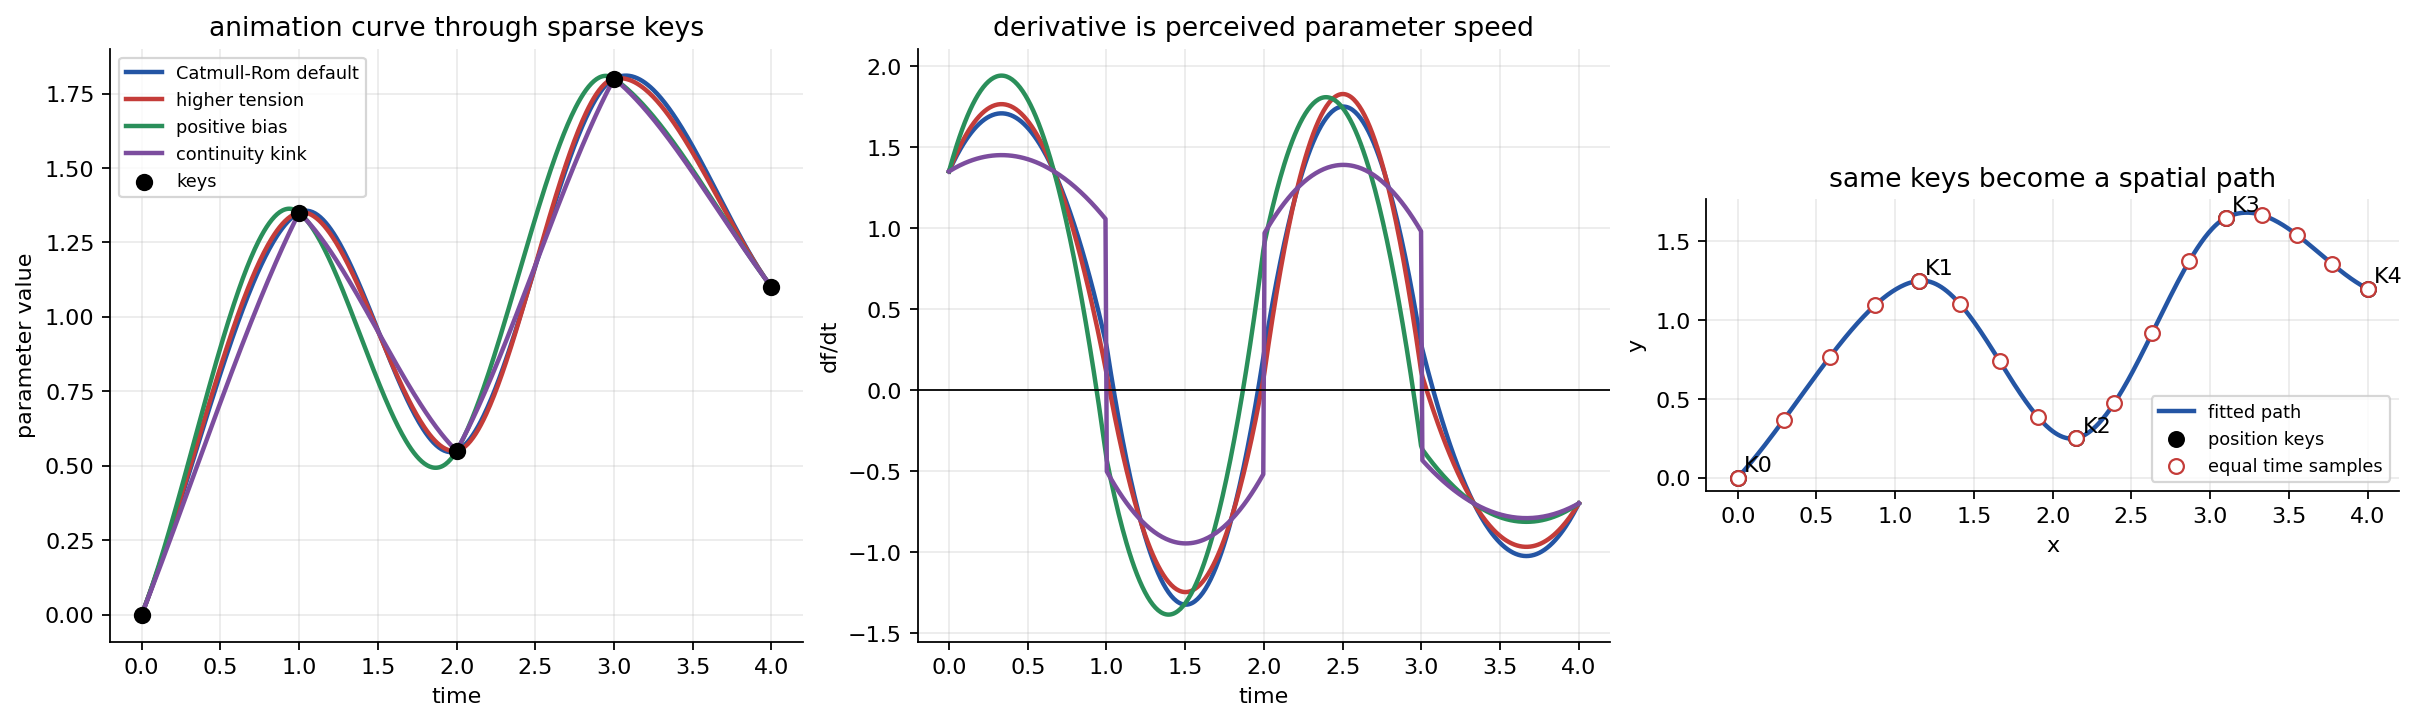

In [3]:
display_artifact(keyframe_path, width=980)

## 2. Path Shape Is Not Timing

The chapter separates the geometric path from motion along the path. A curve `P(u)` tells us where the object could be. A distance-time function `s(t)` tells us how far along that path the object should be at a frame time. The bridge is an arc-length table: sample the curve densely, accumulate chord lengths, then invert the table to find `u(s)`.

This distinction matters because equal steps in a spline parameter are not equal steps in space. The left panel below intentionally keeps the same path for three frame sequences. The raw parameter sequence bunches up and spreads out because the parameter is not physical distance. Constant arc-length sampling makes the spacing uniform. Eased arc-length sampling preserves the path but changes speed in a deliberate slow-in/slow-out pattern.

In [4]:
def arc_length_table(times, values, sample_count=900):
    u = np.linspace(times[0], times[-1], sample_count)
    pts = evaluate_tcb(times, values, u)
    seg = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    s = np.concatenate([[0.0], np.cumsum(seg)])
    return u, pts, s


def sample_by_distance(times, values, distances, u_table, s_table):
    distances = np.clip(distances, 0.0, s_table[-1])
    u = np.interp(distances, s_table, u_table)
    return evaluate_tcb(times, values, u), u


u_table, path_table, s_table = arc_length_table(key_times, path_keys)
total_length = float(s_table[-1])
frame_count = 28
clock = np.linspace(0.0, 1.0, frame_count)
raw_u = np.linspace(key_times[0], key_times[-1], frame_count)
raw_pts = evaluate_tcb(key_times, path_keys, raw_u)
constant_dist = total_length * clock
constant_pts, constant_u = sample_by_distance(key_times, path_keys, constant_dist, u_table, s_table)
eased_dist = total_length * smoothstep(clock)
eased_pts, eased_u = sample_by_distance(key_times, path_keys, eased_dist, u_table, s_table)

spacing = {
    "raw_parameter": np.linalg.norm(np.diff(raw_pts, axis=0), axis=1),
    "constant_arc_length": np.linalg.norm(np.diff(constant_pts, axis=0), axis=1),
    "eased_arc_length": np.linalg.norm(np.diff(eased_pts, axis=0), axis=1),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
axes[0].plot(path_table[:, 0], path_table[:, 1], color="0.72", lw=3, label="P(u)")
axes[0].scatter(raw_pts[:, 0], raw_pts[:, 1], s=24, color="#c43c39", label="equal u")
axes[0].scatter(constant_pts[:, 0], constant_pts[:, 1], s=20, color="#2455a4", label="equal arc length")
axes[0].scatter(eased_pts[:, 0], eased_pts[:, 1], s=20, facecolors="white", edgecolors="#2a8f5a", label="eased s(t)")
axes[0].scatter(path_keys[:, 0], path_keys[:, 1], color="black", s=44, zorder=4)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("one path, three timing laws")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(fontsize=8)

for name, vals in spacing.items():
    axes[1].plot(np.arange(len(vals)), vals, marker="o", ms=3, label=name.replace("_", " "))
axes[1].set_title("frame-to-frame path distance")
axes[1].set_xlabel("frame interval")
axes[1].set_ylabel("distance")
axes[1].legend(fontsize=8)

axes[2].plot(clock, constant_dist, color="#2455a4", lw=2, label="linear s(t)")
axes[2].plot(clock, eased_dist, color="#2a8f5a", lw=2, label="smoothstep s(t)")
axes[2].plot(clock, total_length * raw_u / raw_u[-1], color="#c43c39", lw=1.5, ls="--", label="raw u scaled")
axes[2].set_title("distance-time controls velocity")
axes[2].set_xlabel("normalized time")
axes[2].set_ylabel("distance along path")
axes[2].legend(fontsize=8)

motion_checks = {}
for name, vals in spacing.items():
    motion_checks[name] = {
        "mean_step": float(np.mean(vals)),
        "max_step": float(np.max(vals)),
        "min_step": float(np.min(vals)),
        "coefficient_of_variation": float(np.std(vals) / np.mean(vals)),
    }
motion_checks["arc_length_table"] = {
    "samples": int(len(u_table)),
    "total_length": total_length,
    "monotone_non_decreasing": bool(np.all(np.diff(s_table) >= -1e-12)),
}
path_timing_path = save_matplotlib(fig, TOPIC, "path-arc-length-timing-diagnostics.png")
plt.close(fig)
figure_paths.append(path_timing_path)
path_timing_checks_path = save_json(motion_checks, TOPIC, "path-timing-diagnostics.json")
check_paths.append(path_timing_checks_path)
path_timing_path, path_timing_checks_path, motion_checks

(WindowsPath('artifacts/chapter-16/figures/path-arc-length-timing-diagnostics.png'),
 WindowsPath('artifacts/chapter-16/checks/path-timing-diagnostics.json'),
 {'raw_parameter': {'mean_step': 0.22071642124681218,
   'max_step': 0.3131267684096844,
   'min_step': 0.13567617463057913,
   'coefficient_of_variation': 0.26018058232609015},
  'constant_arc_length': {'mean_step': 0.22016640623920158,
   'max_step': 0.22145442660426123,
   'min_step': 0.20757873877709465,
   'coefficient_of_variation': 0.013046044666972446},
  'eased_arc_length': {'mean_step': 0.219438977617053,
   'max_step': 0.3301115226943469,
   'min_step': 0.023995266465267284,
   'coefficient_of_variation': 0.4424515299979766},
  'arc_length_table': {'samples': 900,
   'total_length': 5.979215163540494,
   'monotone_non_decreasing': True}})

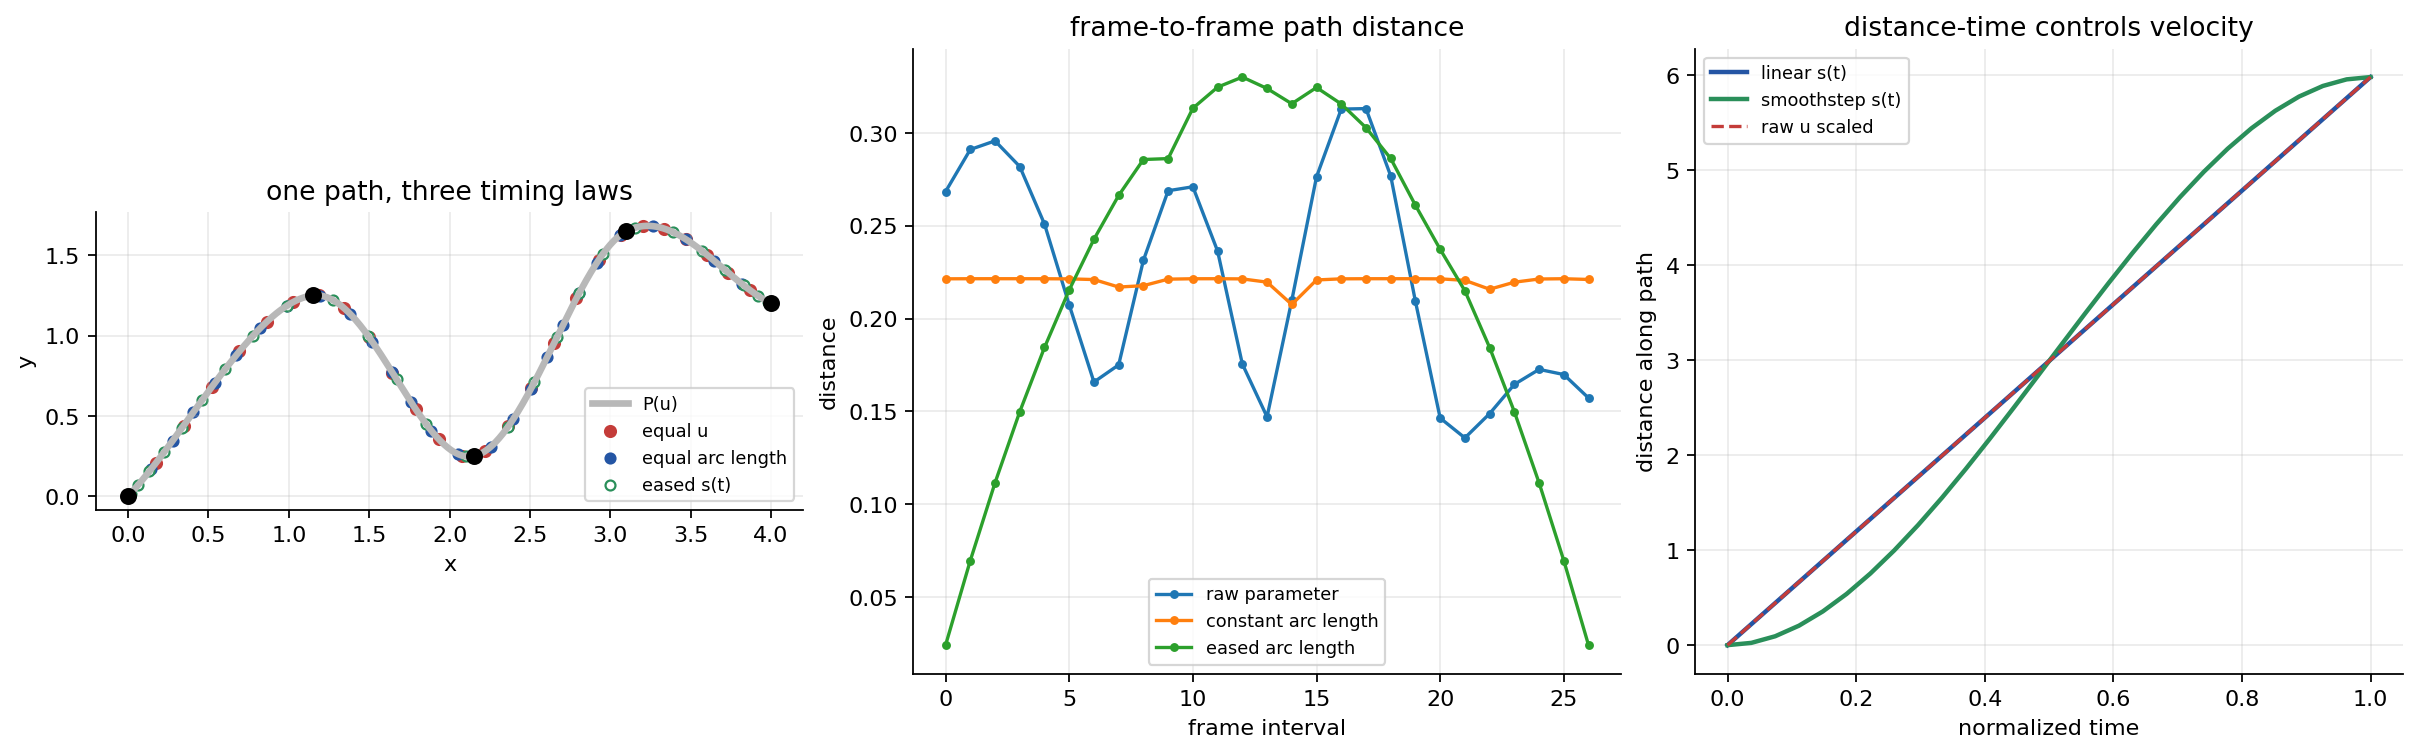

In [5]:
display_artifact(path_timing_path, width=980)
display_artifact(path_timing_checks_path)

## 3. Timing, Aliasing, and Squash/Stretch

Timing is not just a number of frames. The same pose sequence can read as heavy, light, abrupt, relaxed, or invisible depending on frame spacing. When a moving object travels farther than its own width between frames, the eye may see strobing: successive samples do not overlap enough to connect into one motion.

Traditional squash and stretch has a computational invariant: if an object is meant to be elastic rather than growing, its area or volume should stay roughly constant. The next lab keeps a 2D ball's area fixed while stretching it along the direction of travel. The point is not to simulate a material. It is to preserve readability while signaling speed.

In [6]:
from matplotlib.patches import Circle, Ellipse

radius = 0.28
fast_step = 0.86
slow_step = 0.34
frame_ids = np.arange(7)
slow_x = frame_ids * slow_step
fast_x = frame_ids * fast_step
stretch_major = 0.52
stretch_minor = radius**2 / stretch_major
stretch_area = math.pi * stretch_major * stretch_minor
circle_area = math.pi * radius**2

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for x in slow_x:
    axes[0].add_patch(Circle((x, 0.0), radius, facecolor="#9ecae1", edgecolor="#2455a4", alpha=0.78))
axes[0].set_title("slow enough: frame samples overlap")
axes[0].set_xlim(-0.4, slow_x[-1] + 0.4)
axes[0].set_ylim(-0.55, 0.55)
axes[0].set_aspect("equal")
axes[0].set_yticks([])
axes[0].set_xlabel("position sampled once per frame")

for x in fast_x:
    axes[1].add_patch(Circle((x, 0.0), radius, facecolor="#f5b7b1", edgecolor="#c43c39", alpha=0.72))
axes[1].set_title("fast rigid samples: no visual overlap")
axes[1].set_xlim(-0.4, fast_x[-1] + 0.4)
axes[1].set_ylim(-0.55, 0.55)
axes[1].set_aspect("equal")
axes[1].set_yticks([])
axes[1].set_xlabel("position sampled once per frame")

for x in fast_x:
    axes[2].add_patch(Ellipse((x, 0.0), width=2 * stretch_major, height=2 * stretch_minor, facecolor="#b7e4c7", edgecolor="#2a8f5a", alpha=0.75))
axes[2].set_title("stretched pose: overlap with area held constant")
axes[2].set_xlim(-0.4, fast_x[-1] + 0.4)
axes[2].set_ylim(-0.55, 0.55)
axes[2].set_aspect("equal")
axes[2].set_yticks([])
axes[2].set_xlabel("same centers, different shape cue")

for ax in axes:
    ax.grid(False)
    ax.axhline(0, color="0.85", lw=1)

aliasing_checks = {
    "radius": radius,
    "slow_step": slow_step,
    "fast_step": fast_step,
    "diameter": 2 * radius,
    "slow_overlap_margin": float(2 * radius - slow_step),
    "fast_circle_overlap_margin": float(2 * radius - fast_step),
    "fast_stretched_overlap_margin": float(2 * stretch_major - fast_step),
    "squash_stretch_area_relative_error": float(abs(stretch_area - circle_area) / circle_area),
}
aliasing_path = save_matplotlib(fig, TOPIC, "timing-easing-aliasing-lab.png")
plt.close(fig)
figure_paths.append(aliasing_path)
aliasing_checks_path = save_json(aliasing_checks, TOPIC, "timing-aliasing-checks.json")
check_paths.append(aliasing_checks_path)
aliasing_path, aliasing_checks

(WindowsPath('artifacts/chapter-16/figures/timing-easing-aliasing-lab.png'),
 {'radius': 0.28,
  'slow_step': 0.34,
  'fast_step': 0.86,
  'diameter': 0.56,
  'slow_overlap_margin': 0.22000000000000003,
  'fast_circle_overlap_margin': -0.29999999999999993,
  'fast_stretched_overlap_margin': 0.18000000000000005,
  'squash_stretch_area_relative_error': 1.126897208568423e-16})

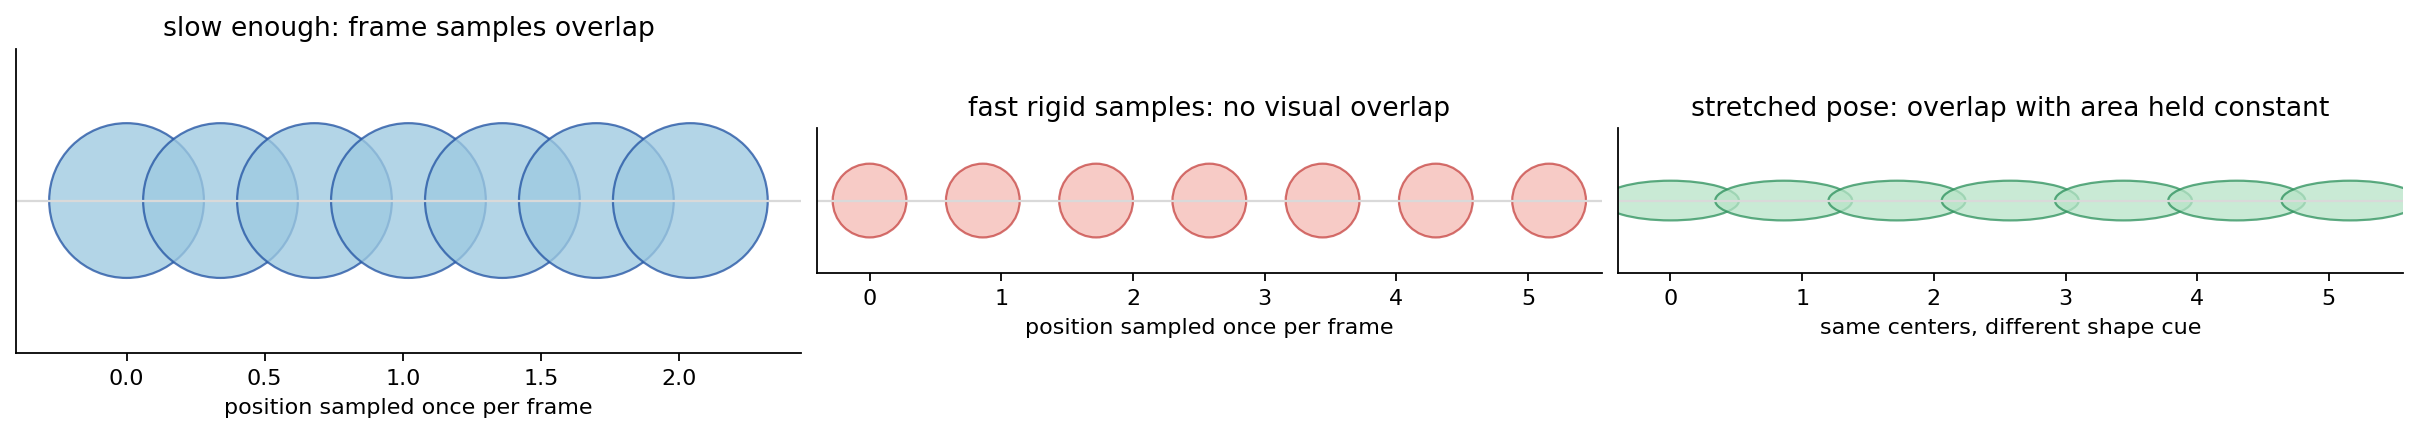

In [7]:
display_artifact(aliasing_path, width=980)
display_artifact(aliasing_checks_path)

## 4. Orientation Belongs on the Rotation Group

A rotation matrix is not just nine numbers. Its columns must remain orthonormal and its determinant must stay `+1`. Elementwise interpolation between two valid rotation matrices usually leaves that set, so the object scales, shears, or collapses while it is supposed to stay rigid.

Quaternions store an axis/angle rotation as a unit point in 4D. The book notes that true spherical interpolation is mathematically heavier, while normalized linear interpolation is often acceptable. The check below compares three things: bad matrix lerp, normalized quaternion lerp, and slerp. The important diagnostic is not whether the object moves. It is whether every intermediate transform remains a valid rotation and whether angular speed changes smoothly enough for the shot.

In [8]:
def quat_normalize(q):
    q = np.asarray(q, dtype=float)
    return q / np.linalg.norm(q)


def axis_angle_to_quat(axis, angle):
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)
    return quat_normalize(np.r_[math.cos(angle / 2.0), math.sin(angle / 2.0) * axis])


def quat_to_matrix(q):
    q = quat_normalize(q)
    w, x, y, z = q
    return np.array([
        [1 - 2 * (y * y + z * z), 2 * (x * y - z * w), 2 * (x * z + y * w)],
        [2 * (x * y + z * w), 1 - 2 * (x * x + z * z), 2 * (y * z - x * w)],
        [2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x * x + y * y)],
    ])


def nlerp(q0, q1, a):
    return quat_normalize((1.0 - a) * q0 + a * q1)


def slerp(q0, q1, a):
    q0 = quat_normalize(q0)
    q1 = quat_normalize(q1)
    dot = float(np.dot(q0, q1))
    if dot < 0.0:
        q1 = -q1
        dot = -dot
    if dot > 0.9995:
        return nlerp(q0, q1, a)
    theta0 = math.acos(np.clip(dot, -1.0, 1.0))
    sin_theta0 = math.sin(theta0)
    return (math.sin((1.0 - a) * theta0) / sin_theta0) * q0 + (math.sin(a * theta0) / sin_theta0) * q1


def quat_angle_between(qa, qb):
    dot = abs(float(np.dot(quat_normalize(qa), quat_normalize(qb))))
    return 2.0 * math.acos(np.clip(dot, -1.0, 1.0))


q0 = axis_angle_to_quat([0, 0, 1], 0.0)
q1 = axis_angle_to_quat([1.0, 0.7, 0.25], math.radians(168.0))
R0 = quat_to_matrix(q0)
R1 = quat_to_matrix(q1)
alpha = np.linspace(0.0, 1.0, 13)
R_lerp = [(1.0 - a) * R0 + a * R1 for a in alpha]
q_nlerp = [nlerp(q0, q1, a) for a in alpha]
q_slerp = [quat_normalize(slerp(q0, q1, a)) for a in alpha]
R_slerp = [quat_to_matrix(q) for q in q_slerp]

matrix_lerp_orth_error = [float(np.linalg.norm(R.T @ R - np.eye(3), ord="fro")) for R in R_lerp]
matrix_lerp_det = [float(np.linalg.det(R)) for R in R_lerp]
slerp_orth_error = [float(np.linalg.norm(R.T @ R - np.eye(3), ord="fro")) for R in R_slerp]
slerp_det = [float(np.linalg.det(R)) for R in R_slerp]
nlerp_steps = np.array([quat_angle_between(q_nlerp[i], q_nlerp[i + 1]) for i in range(len(q_nlerp) - 1)])
slerp_steps = np.array([quat_angle_between(q_slerp[i], q_slerp[i + 1]) for i in range(len(q_slerp) - 1)])

fig = plt.figure(figsize=(15, 4.8), constrained_layout=True)
ax0 = fig.add_subplot(1, 3, 1, projection="3d")
axis_colors = ["#c43c39", "#2a8f5a", "#2455a4"]
axis_names = ["x", "y", "z"]
for idx, q in enumerate(q_slerp[::3]):
    R = quat_to_matrix(q)
    origin = np.array([idx * 1.25, 0.0, 0.0])
    for axis_index, color in enumerate(axis_colors):
        vec = R @ np.eye(3)[axis_index] * 0.48
        ax0.plot([origin[0], origin[0] + vec[0]], [origin[1], origin[1] + vec[1]], [origin[2], origin[2] + vec[2]], color=color, lw=2)
        if idx == 0:
            ax0.text(origin[0] + vec[0], origin[1] + vec[1], origin[2] + vec[2], axis_names[axis_index], color=color)
    ax0.scatter(*origin, color="black", s=14)
ax0.set_title("slerp keeps a rigid local frame")
ax0.set_xlabel("sample")
ax0.set_ylabel("y")
ax0.set_zlabel("z")
ax0.view_init(elev=22, azim=-56)
ax0.set_box_aspect([4.0, 1.5, 1.5])

ax1 = fig.add_subplot(1, 3, 2)
ax1.plot(alpha, matrix_lerp_orth_error, marker="o", color="#c43c39", label="matrix lerp orthonormality error")
ax1.plot(alpha, slerp_orth_error, marker="s", color="#2455a4", label="slerp orthonormality error")
ax1.set_yscale("symlog", linthresh=1e-12)
ax1.set_xlabel("interpolation fraction")
ax1.set_ylabel("||R^T R - I||")
ax1.set_title("bad matrix interpolation leaves SO(3)")
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(1, 3, 3)
ax2.plot(alpha, matrix_lerp_det, marker="o", color="#c43c39", label="det matrix lerp")
ax2.plot(alpha, slerp_det, marker="s", color="#2455a4", label="det slerp")
ax2.axhline(1.0, color="black", lw=0.9)
ax2.set_xlabel("interpolation fraction")
ax2.set_ylabel("determinant")
ax2.set_title("rotation determinant should be +1")
ax2.legend(fontsize=8)

orientation_png_path = save_matplotlib(fig, TOPIC, "orientation-quaternion-transform-check.png")
plt.close(fig)
figure_paths.append(orientation_png_path)

import plotly.graph_objects as go
plotly_fig = go.Figure()
for method_name, qseq, y_offset in [("nlerp", q_nlerp[::2], -0.75), ("slerp", q_slerp[::2], 0.75)]:
    for idx, q in enumerate(qseq):
        R = quat_to_matrix(q)
        origin = np.array([idx * 1.15, y_offset, 0.0])
        for axis_index, color in enumerate(axis_colors):
            vec = R @ np.eye(3)[axis_index] * 0.45
            plotly_fig.add_trace(go.Scatter3d(
                x=[origin[0], origin[0] + vec[0]],
                y=[origin[1], origin[1] + vec[1]],
                z=[origin[2], origin[2] + vec[2]],
                mode="lines",
                line=dict(color=color, width=5),
                name=f"{method_name} {axis_names[axis_index]}",
                showlegend=(idx == 0),
            ))
    plotly_fig.add_trace(go.Scatter3d(x=[0], y=[y_offset], z=[0], mode="text", text=[method_name], showlegend=False))
plotly_fig.update_layout(
    title="Quaternion interpolation frames: rotate to inspect axes",
    scene=dict(aspectmode="data", xaxis_title="sample", yaxis_title="method", zaxis_title="axis height"),
    margin=dict(l=0, r=0, b=0, t=40),
    height=520,
)
orientation_html_path = save_plotly_html(plotly_fig, TOPIC, "orientation-quaternion-interpolation.html")
html_paths.append(orientation_html_path)

orientation_checks = {
    "max_quaternion_norm_error_nlerp": float(max(abs(np.linalg.norm(q) - 1.0) for q in q_nlerp)),
    "max_quaternion_norm_error_slerp": float(max(abs(np.linalg.norm(q) - 1.0) for q in q_slerp)),
    "max_slerp_orthonormality_error": float(max(slerp_orth_error)),
    "min_slerp_determinant": float(min(slerp_det)),
    "max_matrix_lerp_orthonormality_error": float(max(matrix_lerp_orth_error)),
    "min_matrix_lerp_determinant": float(min(matrix_lerp_det)),
    "nlerp_angular_step_cv": float(np.std(nlerp_steps) / np.mean(nlerp_steps)),
    "slerp_angular_step_cv": float(np.std(slerp_steps) / np.mean(slerp_steps)),
}
orientation_checks_path = save_json(orientation_checks, TOPIC, "orientation-transform-checks.json")
check_paths.append(orientation_checks_path)
orientation_png_path, orientation_html_path, orientation_checks

(WindowsPath('artifacts/chapter-16/figures/orientation-quaternion-transform-check.png'),
 WindowsPath('artifacts/chapter-16/html/orientation-quaternion-interpolation.html'),
 {'max_quaternion_norm_error_nlerp': 2.220446049250313e-16,
  'max_quaternion_norm_error_slerp': 1.1102230246251565e-16,
  'max_slerp_orthonormality_error': 1.1940732856230915e-15,
  'min_slerp_determinant': 1.0,
  'max_matrix_lerp_orthonormality_error': 1.398761582666773,
  'min_matrix_lerp_determinant': 0.010926199633097175,
  'nlerp_angular_step_cv': 0.17316447358520493,
  'slerp_angular_step_cv': 4.799145813927471e-15})

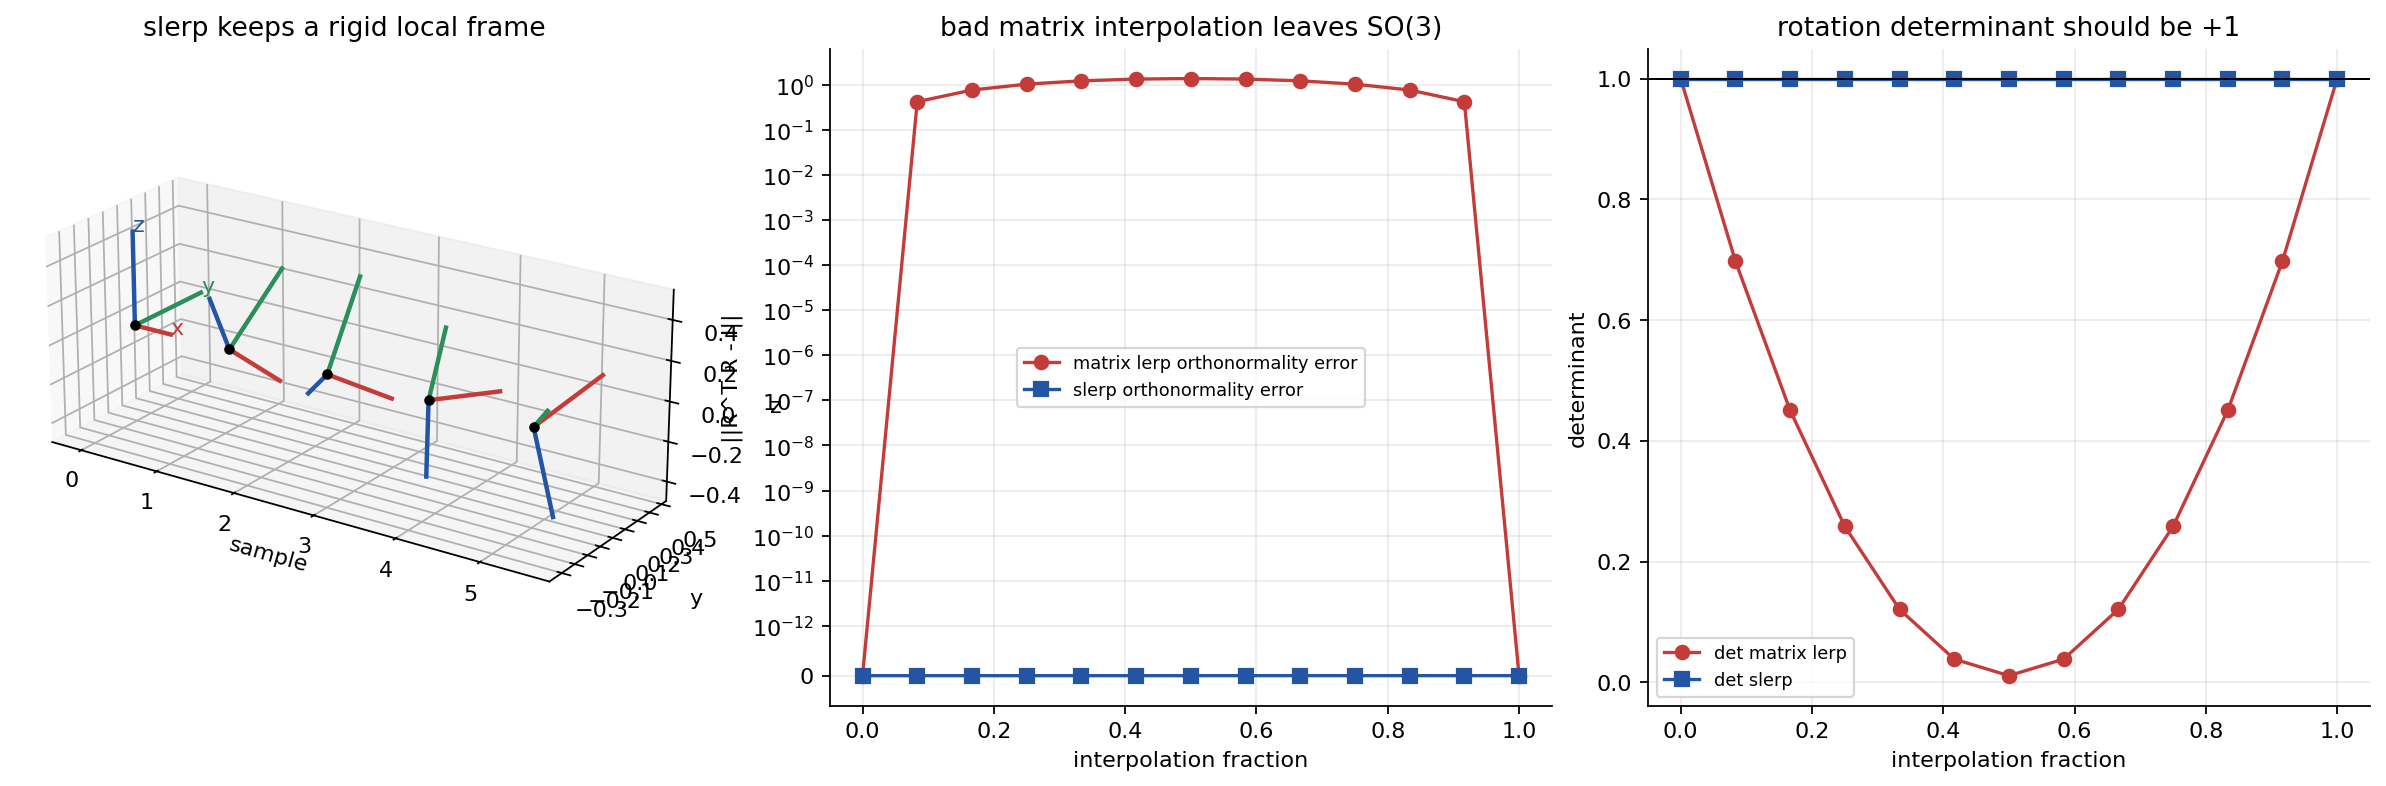

In [9]:
display_artifact(orientation_png_path, width=980)
display_artifact(orientation_html_path, width="100%", height=540)
display_artifact(orientation_checks_path)

## 5. Character Control: FK, IK, Jacobians, and Skinning

The source chapter treats a character skeleton as a hierarchy of joints. Forward kinematics composes local transforms from the root outward. It is predictable, but asking an animator to set every internal joint is tedious. Inverse kinematics turns the problem around: the animator moves an end effector, and the system solves for internal joint parameters.

For a two-link arm, we can see both the exact geometric solutions and the iterative Jacobian idea. The Jacobian says how a small joint-angle change moves the end effector. The same skeleton can also deform skin. Rigid skinning assigns a vertex to one joint; smooth skinning blends several joint transforms with weights. The invariant for the blend is simple: weights should sum to one unless a deliberate scale effect is intended.

In [10]:
L1, L2 = 1.55, 1.05


def fk_arm(theta):
    t1, t2 = theta
    root = np.array([0.0, 0.0])
    elbow = np.array([L1 * math.cos(t1), L1 * math.sin(t1)])
    wrist = elbow + np.array([L2 * math.cos(t1 + t2), L2 * math.sin(t1 + t2)])
    return np.vstack([root, elbow, wrist])


def jacobian_arm(theta):
    t1, t2 = theta
    return np.array([
        [-L1 * math.sin(t1) - L2 * math.sin(t1 + t2), -L2 * math.sin(t1 + t2)],
        [L1 * math.cos(t1) + L2 * math.cos(t1 + t2), L2 * math.cos(t1 + t2)],
    ])


def numerical_jacobian(theta, eps=1e-6):
    base = fk_arm(theta)[-1]
    J = np.zeros((2, 2))
    for i in range(2):
        shifted = np.array(theta, dtype=float)
        shifted[i] += eps
        J[:, i] = (fk_arm(shifted)[-1] - base) / eps
    return J


def analytic_ik(target, elbow_sign=1.0):
    x, y = target
    r2 = x * x + y * y
    cos2 = np.clip((r2 - L1 * L1 - L2 * L2) / (2 * L1 * L2), -1.0, 1.0)
    t2 = elbow_sign * math.acos(cos2)
    t1 = math.atan2(y, x) - math.atan2(L2 * math.sin(t2), L1 + L2 * math.cos(t2))
    return np.array([t1, t2])


target = np.array([1.52, 1.08])
solutions = [analytic_ik(target, 1.0), analytic_ik(target, -1.0)]
angles = np.array([math.radians(8.0), math.radians(-35.0)])
iter_path = [fk_arm(angles)[-1]]
for _ in range(36):
    wrist = fk_arm(angles)[-1]
    error = target - wrist
    if np.linalg.norm(error) < 1e-5:
        break
    J = jacobian_arm(angles)
    damping = 2e-3
    delta = J.T @ np.linalg.solve(J @ J.T + damping * np.eye(2), 0.7 * error)
    angles = angles + np.clip(delta, -0.28, 0.28)
    iter_path.append(fk_arm(angles)[-1])
iter_path = np.array(iter_path)

jacobian_error = float(np.linalg.norm(jacobian_arm(angles) - numerical_jacobian(angles)))
ik_residual = float(np.linalg.norm(fk_arm(angles)[-1] - target))

xs = np.linspace(0.0, 2.2, 33)
ys = np.linspace(-0.18, 0.18, 7)
X, Y = np.meshgrid(xs, ys)
skin = np.c_[X.ravel(), Y.ravel()]
joint = np.array([1.05, 0.0])
bend = math.radians(62.0)
R = np.array([[math.cos(bend), -math.sin(bend)], [math.sin(bend), math.cos(bend)]])
transformed_by_bone0 = skin.copy()
transformed_by_bone1 = joint + (skin - joint) @ R.T
w1 = smoothstep((skin[:, 0] - 0.78) / 0.58)
w0 = 1.0 - w1
rigid_skin = np.where((skin[:, 0] < joint[0])[:, None], transformed_by_bone0, transformed_by_bone1)
smooth_skin = w0[:, None] * transformed_by_bone0 + w1[:, None] * transformed_by_bone1
weight_sum_error = float(np.max(np.abs(w0 + w1 - 1.0)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
workspace = plt.Circle((0, 0), L1 + L2, color="0.88", fill=False, ls="--")
axes[0].add_patch(workspace)
for sol, color, label in zip(solutions, ["#2455a4", "#2a8f5a"], ["elbow-up IK", "elbow-down IK"]):
    pts = fk_arm(sol)
    axes[0].plot(pts[:, 0], pts[:, 1], marker="o", color=color, lw=2, label=label)
axes[0].plot(iter_path[:, 0], iter_path[:, 1], color="#c43c39", marker=".", label="Jacobian iteration")
axes[0].scatter([target[0]], [target[1]], marker="x", s=90, color="black", label="target")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("IK can have multiple valid poses")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(fontsize=8)

axes[1].plot(np.linalg.norm(iter_path - target, axis=1), marker="o", color="#c43c39")
axes[1].set_yscale("log")
axes[1].set_title("end-effector residual during IK")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("distance to target")

for row in range(len(ys)):
    sl = slice(row * len(xs), (row + 1) * len(xs))
    axes[2].plot(rigid_skin[sl, 0], rigid_skin[sl, 1], color="#c43c39", alpha=0.55, lw=1)
    axes[2].plot(smooth_skin[sl, 0], smooth_skin[sl, 1], color="#2455a4", alpha=0.8, lw=1.5)
for col in range(len(xs)):
    idx = np.arange(col, skin.shape[0], len(xs))
    axes[2].plot(smooth_skin[idx, 0], smooth_skin[idx, 1], color="#2455a4", alpha=0.25, lw=0.8)
axes[2].scatter([joint[0]], [joint[1]], color="black", s=34, zorder=5, label="joint")
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_title("rigid skinning kink vs smooth weight blend")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].legend(["rigid", "smooth", "joint"], fontsize=8)

kinematic_checks = {
    "ik_target": target.tolist(),
    "ik_iterations": int(len(iter_path) - 1),
    "ik_residual": ik_residual,
    "jacobian_finite_difference_error": jacobian_error,
    "solution_count_for_target": len(solutions),
    "smooth_skinning_weight_sum_error": weight_sum_error,
    "skin_vertex_count": int(skin.shape[0]),
}
kinematic_path = save_matplotlib(fig, TOPIC, "skeletal-ik-skinning-diagnostics.png")
plt.close(fig)
figure_paths.append(kinematic_path)
kinematic_checks_path = save_json(kinematic_checks, TOPIC, "kinematic-skinning-checks.json")
check_paths.append(kinematic_checks_path)
kinematic_path, kinematic_checks

(WindowsPath('artifacts/chapter-16/figures/skeletal-ik-skinning-diagnostics.png'),
 {'ik_target': [1.52, 1.08],
  'ik_iterations': 12,
  'ik_residual': 8.180028637584174e-06,
  'jacobian_finite_difference_error': 1.069911639193125e-06,
  'solution_count_for_target': 2,
  'smooth_skinning_weight_sum_error': 0.0,
  'skin_vertex_count': 231})

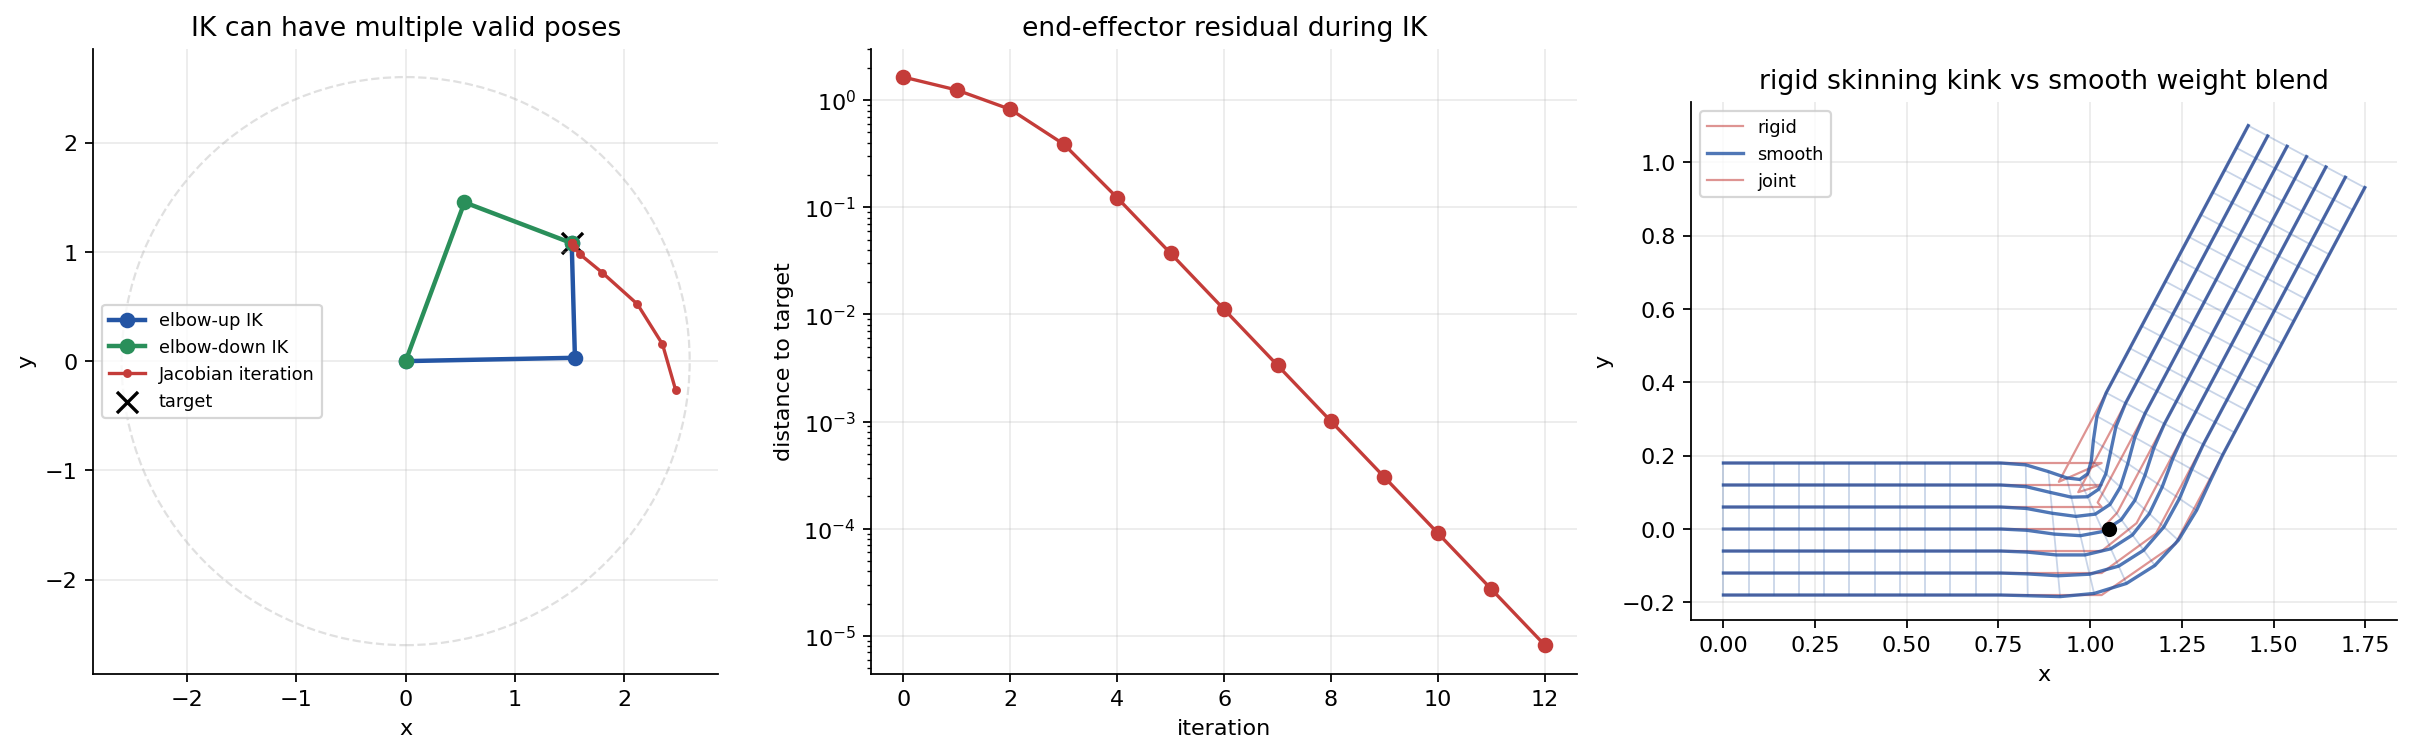

In [11]:
display_artifact(kinematic_path, width=980)
display_artifact(kinematic_checks_path)

## 6. Automatic Motion: Physics, Procedures, and Groups

The last sections of the chapter broaden the control vocabulary. Physics-based animation solves a difference equation instead of asking the animator to place every frame. Procedural animation writes functions whose outputs resemble the desired motion without necessarily solving the underlying physics. Group animation computes local decisions that can create coordinated behavior.

The tradeoff is control. A finite-difference update can be accurate enough but unstable. A procedural wave can be cheap and plausible, but its parameters are not the same as a physical fluid. A group controller must negotiate competing urges without averaging them into cancellation. The compact diagnostic below keeps those three warnings visible.

In [12]:
def oscillator(method, dt=0.42, steps=90):
    x = 1.0
    v = 0.0
    xs = []
    energy = []
    for _ in range(steps):
        xs.append(x)
        energy.append(0.5 * (x * x + v * v))
        if method == "explicit":
            x, v = x + dt * v, v - dt * x
        elif method == "symplectic":
            v = v - dt * x
            x = x + dt * v
        else:
            raise ValueError(method)
    return np.array(xs), np.array(energy)


explicit_x, explicit_energy = oscillator("explicit")
symplectic_x, symplectic_energy = oscillator("symplectic")
xgrid = np.linspace(0.0, 2.5 * math.pi, 220)
wave_times = [0.0, 0.65, 1.3]
waves = [0.5 * np.cos(2.3 * t - 1.4 * xgrid + 0.25) + 0.18 * np.cos(4.1 * t - 3.2 * xgrid + 1.1) for t in wave_times]

urge_vectors = [
    ("collision", np.array([-0.45, 0.74]), "#c43c39"),
    ("velocity match", np.array([0.38, 0.16]), "#7c4d9e"),
    ("cohesion", np.array([0.52, -0.16]), "#2a8f5a"),
    ("goal", np.array([0.80, 0.02]), "#2455a4"),
]
accel_budget = 1.35
remaining = accel_budget
allocated = []
for name, vec, color in urge_vectors:
    mag = np.linalg.norm(vec)
    take = min(mag, remaining)
    contribution = np.zeros(2) if mag == 0 else vec / mag * take
    allocated.append((name, contribution, color))
    remaining -= take
final_accel = sum((vec for _, vec, _ in allocated), start=np.zeros(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
axes[0].plot(explicit_energy, color="#c43c39", label="explicit Euler")
axes[0].plot(symplectic_energy, color="#2455a4", label="symplectic Euler")
axes[0].set_yscale("log")
axes[0].set_title("finite-difference stability matters")
axes[0].set_xlabel("step")
axes[0].set_ylabel("oscillator energy")
axes[0].legend(fontsize=8)

for t, y in zip(wave_times, waves):
    axes[1].plot(xgrid, y, lw=2, label=f"t={t:.2f}")
axes[1].set_title("procedural motion exposes parameters")
axes[1].set_xlabel("x")
axes[1].set_ylabel("height")
axes[1].legend(fontsize=8)

for name, vec, color in urge_vectors:
    axes[2].arrow(0, 0, vec[0], vec[1], width=0.012, length_includes_head=True, color=color, alpha=0.42)
    axes[2].text(vec[0] * 1.05, vec[1] * 1.05, name, color=color, fontsize=8)
for name, vec, color in allocated:
    axes[2].arrow(0, 0, vec[0], vec[1], width=0.018, length_includes_head=True, color=color)
axes[2].arrow(0, 0, final_accel[0], final_accel[1], width=0.024, length_includes_head=True, color="black")
axes[2].text(final_accel[0] * 1.05, final_accel[1] * 1.05, "allocated", color="black", fontsize=8)
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_title("priority allocation avoids urge cancellation")
axes[2].set_xlim(-0.8, 1.2)
axes[2].set_ylim(-0.45, 1.05)
axes[2].set_xlabel("accel x")
axes[2].set_ylabel("accel y")

automatic_checks = {
    "explicit_energy_growth_factor": float(explicit_energy[-1] / explicit_energy[0]),
    "symplectic_energy_growth_factor": float(symplectic_energy[-1] / symplectic_energy[0]),
    "procedural_wave_time_samples": wave_times,
    "acceleration_budget": accel_budget,
    "allocated_acceleration_norm": float(np.linalg.norm(final_accel)),
    "budget_remaining_after_priorities": float(remaining),
}
automatic_path = save_matplotlib(fig, TOPIC, "automatic-methods-control-diagnostics.png")
plt.close(fig)
figure_paths.append(automatic_path)
automatic_checks_path = save_json(automatic_checks, TOPIC, "automatic-methods-checks.json")
check_paths.append(automatic_checks_path)
automatic_path, automatic_checks

(WindowsPath('artifacts/chapter-16/figures/automatic-methods-control-diagnostics.png'),
 {'explicit_energy_growth_factor': 1902814.3120692377,
  'symplectic_energy_growth_factor': 1.0167762827371778,
  'procedural_wave_time_samples': [0.0, 0.65, 1.3],
  'acceleration_budget': 1.35,
  'allocated_acceleration_norm': 0.8789429850683417,
  'budget_remaining_after_priorities': 0.0})

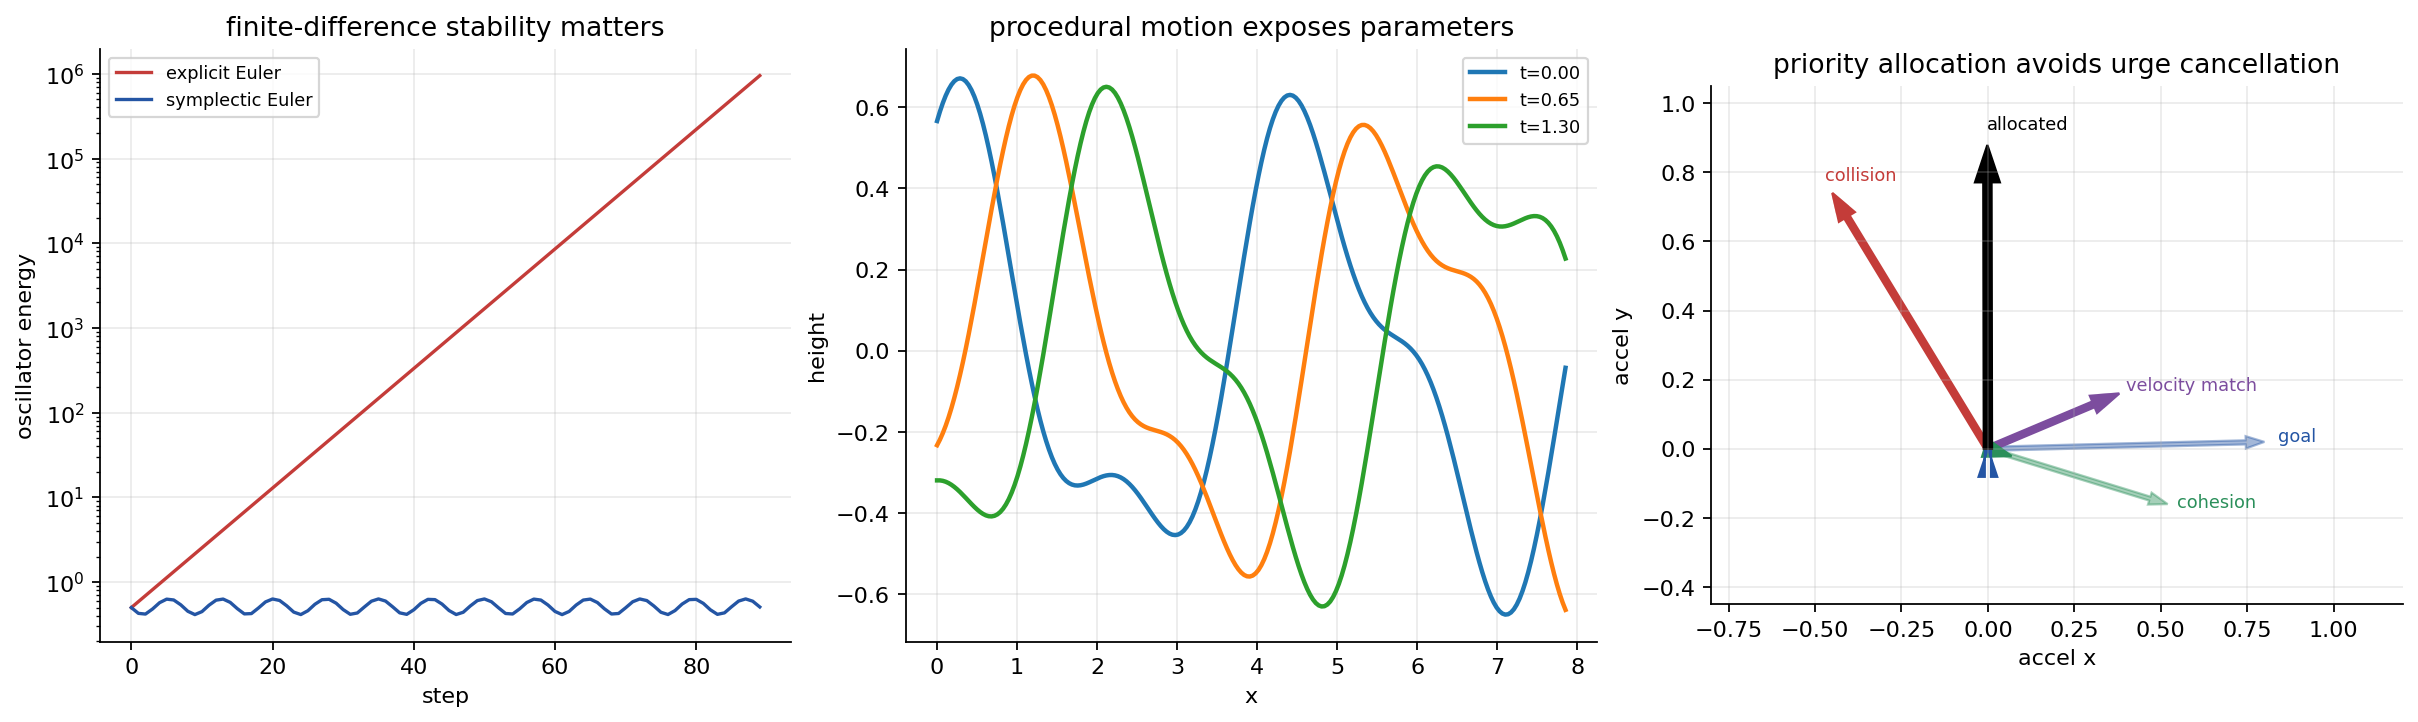

In [13]:
display_artifact(automatic_path, width=980)
display_artifact(automatic_checks_path)

## Applied lab: Debug an Animation Clip

Use the generated functions as a small debugging checklist for a clip you create or import.

1. Pick three to six position keys and evaluate the default Catmull-Rom curve. Plot both the path and the speed. If the path is acceptable but speed is not, leave `P(u)` alone and edit `s(t)` instead.
2. Sample the clip at the intended frame rate. Compare frame-to-frame displacement against the apparent size of the object. If samples do not overlap, decide whether timing, motion blur, or squash/stretch is the right artistic cue.
3. For any rigid orientation, check `R.T @ R` and `det(R)` at intermediate frames. A visually subtle scale/shear error is still a transform bug.
4. For a character limb, check whether FK can pose it directly. If the animator's control is really an end-effector target, use IK and inspect the residual and Jacobian.
5. For automatic motion, ask which parameters the animator can still control. A stable simulation or procedural function is not enough if it cannot be directed.

In [14]:
late_start = np.where(clock < 0.35, 0.0, smoothstep((clock - 0.35) / 0.65))
late_dist = total_length * late_start
late_pts, late_u = sample_by_distance(key_times, path_keys, late_dist, u_table, s_table)
late_steps = np.linalg.norm(np.diff(late_pts, axis=0), axis=1)
lab_checks = {
    "late_start_zero_motion_frames": int(np.sum(late_steps < 1e-9)),
    "late_start_max_step": float(np.max(late_steps)),
    "late_start_mean_step_after_motion_begins": float(np.mean(late_steps[late_steps > 1e-9])),
    "late_start_path_endpoint_error": float(np.linalg.norm(late_pts[-1] - path_keys[-1])),
}
lab_checks_path = save_json(lab_checks, TOPIC, "applied-lab-retiming-checks.json")
check_paths.append(lab_checks_path)
lab_checks

{'late_start_zero_motion_frames': 9,
 'late_start_max_step': 0.5067282185206681,
 'late_start_mean_step_after_motion_begins': 0.323138794026172,
 'late_start_path_endpoint_error': 0.0}

## Sanity checks

The final checks assert the invariants that carry the chapter:

- interpolation reaches the authored keys;
- arc-length tables are monotone;
- squash/stretch preserves area in the timing lab;
- quaternion interpolation remains on the unit sphere and produces valid rotation matrices;
- bad matrix interpolation is caught by determinant and orthonormality checks;
- IK reaches the target and the analytic Jacobian matches finite differences;
- smooth skinning weights sum to one;
- finite-difference, procedural, and group examples record numeric diagnostics;
- every generated artifact exists and every PNG is nonblank.

In [15]:
animation_sanity = {
    "chapter": CHAPTER,
    "title": TITLE,
    "printed_pages": PRINTED_PAGES,
    "pdf_pages": PDF_PAGES,
    "keyframes": keyframe_checks,
    "path_timing": motion_checks,
    "timing_aliasing": aliasing_checks,
    "orientation": orientation_checks,
    "kinematics_and_skinning": kinematic_checks,
    "automatic_methods": automatic_checks,
    "applied_lab": lab_checks,
}

assert animation_sanity["keyframes"]["max_key_interpolation_error"] < 1e-10
assert animation_sanity["path_timing"]["arc_length_table"]["monotone_non_decreasing"]
assert animation_sanity["path_timing"]["constant_arc_length"]["coefficient_of_variation"] < 0.02
assert animation_sanity["timing_aliasing"]["fast_circle_overlap_margin"] < 0.0
assert animation_sanity["timing_aliasing"]["fast_stretched_overlap_margin"] > 0.0
assert animation_sanity["timing_aliasing"]["squash_stretch_area_relative_error"] < 1e-12
assert animation_sanity["orientation"]["max_quaternion_norm_error_slerp"] < 1e-12
assert animation_sanity["orientation"]["max_slerp_orthonormality_error"] < 1e-12
assert animation_sanity["orientation"]["min_slerp_determinant"] > 1.0 - 1e-12
assert animation_sanity["orientation"]["max_matrix_lerp_orthonormality_error"] > 0.1
assert animation_sanity["kinematics_and_skinning"]["ik_residual"] < 5e-4
assert animation_sanity["kinematics_and_skinning"]["jacobian_finite_difference_error"] < 1e-5
assert animation_sanity["kinematics_and_skinning"]["smooth_skinning_weight_sum_error"] < 1e-12
assert animation_sanity["automatic_methods"]["explicit_energy_growth_factor"] > animation_sanity["automatic_methods"]["symplectic_energy_growth_factor"]
assert animation_sanity["applied_lab"]["late_start_path_endpoint_error"] < 1e-9

animation_sanity_path = save_json(animation_sanity, TOPIC, "animation-sanity.json")
numeric_checks_path = save_json(animation_sanity, TOPIC, "numeric-checks.json")
check_paths.extend([animation_sanity_path, numeric_checks_path])

artifact_records = assert_artifacts([*figure_paths, *html_paths, *check_paths])
image_records = [assert_nonblank_image(path) for path in figure_paths]

final_report = {
    "chapter": CHAPTER,
    "title": TITLE,
    "printed_pages": PRINTED_PAGES,
    "pdf_pages": PDF_PAGES,
    "artifact_count": len(figure_paths) + len(html_paths) + len(check_paths),
    "figure_count": len(figure_paths),
    "html_count": len(html_paths),
    "check_count": len(check_paths),
    "nonblank_png_count": len(image_records),
    "storyboard_items_implemented": [
        "keyframe Catmull-Rom and TCB interpolation diagnostics",
        "arc-length path timing and easing lab",
        "frame aliasing plus area-preserving squash/stretch",
        "quaternion orientation interpolation and matrix transform checks",
        "FK/IK Jacobian and smooth skinning diagnostics",
        "physics, procedural wave, and group steering control diagnostics",
    ],
    "artifact_records": artifact_records,
}
final_sanity_path = save_json(final_report, TOPIC, "final-sanity.json")
artifact_records = assert_artifacts([*figure_paths, *html_paths, *check_paths, final_sanity_path])

display_artifact(animation_sanity_path)
display_artifact(final_sanity_path)
final_report

{'chapter': 16,
 'title': 'Computer Animation',
 'printed_pages': '429-460',
 'pdf_pages': '446-477',
 'artifact_count': 15,
 'figure_count': 6,
 'html_count': 1,
 'check_count': 8,
 'nonblank_png_count': 6,
 'storyboard_items_implemented': ['keyframe Catmull-Rom and TCB interpolation diagnostics',
  'arc-length path timing and easing lab',
  'frame aliasing plus area-preserving squash/stretch',
  'quaternion orientation interpolation and matrix transform checks',
  'FK/IK Jacobian and smooth skinning diagnostics',
  'physics, procedural wave, and group steering control diagnostics'],
 'artifact_records': [{'path': 'artifacts/chapter-16/figures/keyframe-tcb-interpolation-diagnostics.png',
   'bytes': 228568},
  {'path': 'artifacts/chapter-16/figures/path-arc-length-timing-diagnostics.png',
   'bytes': 188310},
  {'path': 'artifacts/chapter-16/figures/timing-easing-aliasing-lab.png',
   'bytes': 109557},
  {'path': 'artifacts/chapter-16/figures/orientation-quaternion-transform-check.png

## Takeaways

Animation systems are control systems. A good animation interface lets the artist specify meaningful intent while the computer handles interpolation, constraints, sampling, simulation, or repetition.

The most useful diagnostic habit from this chapter is to separate spaces: value space for keys, curve parameter space for paths, distance space for timing, unit-quaternion space for orientation, joint-parameter space for skeletons, and state space for simulation. Bugs become easier to find when we ask which space an operation is valid in.

The second habit is to sample like a viewer. The final rendered animation is discrete in time, so a mathematically smooth curve can still fail if frame spacing, speed, silhouettes, or transform validity are not inspected at frame times.